### Lab: 공공데이터포탈, 국민건강보험공단 건강검진정보 2024

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("국민건강보험공단_건강검진정보_2024.CSV", encoding='euc-kr')

In [3]:
# df.head()
# df.tail()
# df.sample(5)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   기준년도           1000000 non-null  int64  
 1   가입자일련번호        1000000 non-null  int64  
 2   시도코드           1000000 non-null  int64  
 3   성별코드           1000000 non-null  int64  
 4   연령대코드(5세단위)    1000000 non-null  int64  
 5   신장(5cm단위)      1000000 non-null  int64  
 6   체중(5kg단위)      1000000 non-null  int64  
 7   허리둘레           999505 non-null   float64
 8   시력(좌)          999807 non-null   float64
 9   시력(우)          999808 non-null   float64
 10  청력(좌)          999852 non-null   float64
 11  청력(우)          999852 non-null   float64
 12  수축기혈압          994210 non-null   float64
 13  이완기혈압          994211 non-null   float64
 14  식전혈당(공복혈당)     994153 non-null   float64
 15  총콜레스테롤         342400 non-null   float64
 16  트리글리세라이드       342395 non-null   float64
 17  HDL콜레스테롤       34239

## Missing values

In [13]:
df.isnull().sum()

기준년도                   0
가입자일련번호                0
시도코드                   0
성별코드                   0
연령대코드(5세단위)            0
신장(5cm단위)              0
체중(5kg단위)              0
허리둘레                 495
시력(좌)                193
시력(우)                192
청력(좌)                148
청력(우)                148
수축기혈압               5790
이완기혈압               5789
식전혈당(공복혈당)          5847
총콜레스테롤            657600
트리글리세라이드          657605
HDL콜레스테롤          657603
LDL콜레스테롤          663611
혈색소                 5855
요단백                11319
혈청크레아티닌             5852
혈청지오티(AST)          5848
혈청지피티(ALT)          5848
감마지티피               5848
흡연상태                 118
음주여부                  45
구강검진수검여부               0
치아우식증유무           654572
결손치 유무           1000000
치아마모증유무          1000000
제3대구치(사랑니) 이상    1000000
치석                654572
dtype: int64

In [15]:
# handling missing values
#option #1 : drop
# newdf = df.dropna() #in-place가 아니고 항상 새로운 copy를 반환
# df.dropna(axis=0) #or 'index'
df.dropna(axis=1)

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),구강검진수검여부
0,2024,4831755,41,2,13,160,50,0
1,2024,1154608,41,2,11,155,60,0
2,2024,3318236,41,2,13,150,55,0
3,2024,3770599,41,1,16,160,70,0
4,2024,2634185,41,1,11,175,65,0
...,...,...,...,...,...,...,...,...
999995,2024,1945007,27,2,17,150,45,0
999996,2024,2558884,28,1,12,160,70,0
999997,2024,4441437,41,1,12,160,65,0
999998,2024,4313591,30,1,8,175,95,1


In [6]:
# option 2: use mean values
mean_waist = df["허리둘레"].mean()
mean_eyes_left = df["시력(좌)"].mean()
newdf = df.fillna({'허리둘레' : mean_waist,'시력(좌)':mean_eyes_left})
newdf.isnull().sum()

기준년도                   0
가입자일련번호                0
시도코드                   0
성별코드                   0
연령대코드(5세단위)            0
신장(5cm단위)              0
체중(5kg단위)              0
허리둘레                   0
시력(좌)                  0
시력(우)                192
청력(좌)                148
청력(우)                148
수축기혈압               5790
이완기혈압               5789
식전혈당(공복혈당)          5847
총콜레스테롤            657600
트리글리세라이드          657605
HDL콜레스테롤          657603
LDL콜레스테롤          663611
혈색소                 5855
요단백                11319
혈청크레아티닌             5852
혈청지오티(AST)          5848
혈청지피티(ALT)          5848
감마지티피               5848
흡연상태                 118
음주여부                  45
구강검진수검여부               0
치아우식증유무           654572
결손치 유무           1000000
치아마모증유무          1000000
제3대구치(사랑니) 이상    1000000
치석                654572
dtype: int64

In [7]:
#option 3: fill with neighbor's values
newnewdf = newdf.ffill().bfill()
newnewdf.isnull().sum()

기준년도                   0
가입자일련번호                0
시도코드                   0
성별코드                   0
연령대코드(5세단위)            0
신장(5cm단위)              0
체중(5kg단위)              0
허리둘레                   0
시력(좌)                  0
시력(우)                  0
청력(좌)                  0
청력(우)                  0
수축기혈압                  0
이완기혈압                  0
식전혈당(공복혈당)             0
총콜레스테롤                 0
트리글리세라이드               0
HDL콜레스테롤               0
LDL콜레스테롤               0
혈색소                    0
요단백                    0
혈청크레아티닌                0
혈청지오티(AST)             0
혈청지피티(ALT)             0
감마지티피                  0
흡연상태                   0
음주여부                   0
구강검진수검여부               0
치아우식증유무                0
결손치 유무           1000000
치아마모증유무          1000000
제3대구치(사랑니) 이상    1000000
치석                     0
dtype: int64

### Stats about health

In [8]:
df['신장(5cm단위)'].describe()

count    1000000.000000
mean         162.732935
std            9.355593
min          130.000000
25%          155.000000
50%          165.000000
75%          170.000000
max          195.000000
Name: 신장(5cm단위), dtype: float64

[Text(0.5, 0, 'height(cm)'), Text(0, 0.5, 'count')]

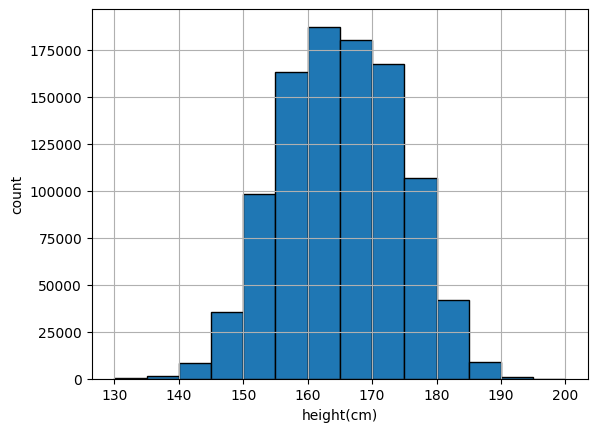

In [16]:
x_bins = np.linspace(130,200,15)
ax = df['신장(5cm단위)'].hist(bins=x_bins,edgecolor='k')
ax.set(xlabel = 'height(cm)',ylabel ='count') 

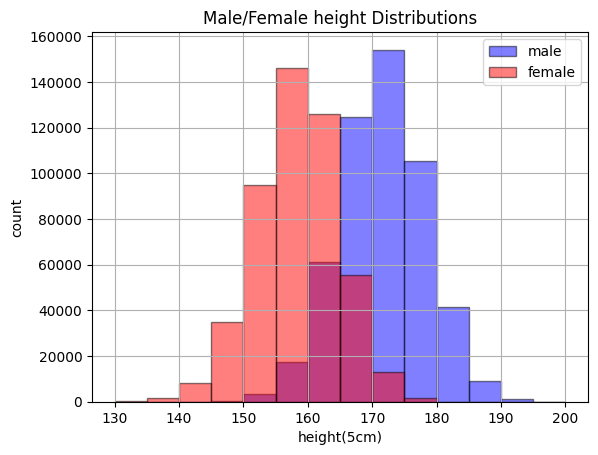

In [10]:
male = df[df['성별코드'] == 1]
female = df[df['성별코드'] == 2]
fig, ax = plt.subplots()
male['신장(5cm단위)'].hist(ax = ax,bins=x_bins,edgecolor='k',color='b',alpha=0.5,label='male')
female['신장(5cm단위)'].hist(ax = ax,bins=x_bins,edgecolor='k',color='r',alpha=0.5,label='female')
ax.legend()
ax.set(xlabel='height(5cm)',ylabel='count')
ax.set_title("Male/Female height Distributions")
ax.legend()